# Análisis de Componentes Principales (PCA) con NumPy

El **Análisis de Componentes Principales** (PCA) es una técnica de reducción de dimensionalidad ampliamente utilizada en ciencia de datos y machine learning. Su objetivo es encontrar una nueva representación de los datos en un espacio de menor dimensión, capturando la mayor variabilidad posible.

## Conceptos Clave

1. **Estandarización de Datos**: Como PCA es sensible a la escala, se recomienda estandarizar los datos antes de aplicar el método.
2. **Matriz de Covarianza**: Nos ayuda a entender la relación entre las variables del dataset.
3. **Descomposición en Valores Propios**: PCA se basa en encontrar los autovalores y autovectores de la matriz de covarianza.
4. **Selección de Componentes Principales**: Se escogen los autovectores con los autovalores más altos para reducir la dimensionalidad.
5. **Transformación de Datos**: Los datos originales se proyectan en los nuevos ejes principales.

## Descarga de librerías necesarias para el notebook

Si no tenéis instaladas las librerías de la próxima celda, simplemente ejecutadla una vez para que se instalen en vuestro entorno.

In [1]:
!pip install -q numpy pandas matplotlib seaborn scikit-learn

In [2]:
import numpy as np
import matplotlib as mpl
import seaborn as sb
import sklearn as sk 
import pandas as pd

Documentación de Numpy: https://numpy.org/doc/

Documentación de Pandas: https://pandas.pydata.org/docs/

## 1. Carga de datos

Carga el dataset del vino desde `sklearn.datasets` y conviértelo en un DataFrame de pandas

In [3]:
from sklearn.datasets import load_wine
data = load_wine()
data = pd.DataFrame(data=data.data, columns = data.feature_names)

## 2. Exploración de Datos

Muestra las primeras filas del DataFrame y calcula estadísticas descriptivas.

In [4]:
# Exploración inicial del dataset
print("\nPrimeras filas del dataset:")
print(data)


Primeras filas del dataset:
     alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0      14.23        1.71  2.43               15.6      127.0           2.80   
1      13.20        1.78  2.14               11.2      100.0           2.65   
2      13.16        2.36  2.67               18.6      101.0           2.80   
3      14.37        1.95  2.50               16.8      113.0           3.85   
4      13.24        2.59  2.87               21.0      118.0           2.80   
..       ...         ...   ...                ...        ...            ...   
173    13.71        5.65  2.45               20.5       95.0           1.68   
174    13.40        3.91  2.48               23.0      102.0           1.80   
175    13.27        4.28  2.26               20.0      120.0           1.59   
176    13.17        2.59  2.37               20.0      120.0           1.65   
177    14.13        4.10  2.74               24.5       96.0           2.05   

     flavanoids  nonfl

In [5]:
print("Resumen estadístico:")
print(data.describe())

Resumen estadístico:
          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.124453         0.5723

## 3. Visualización de Correlaciones

Crea un heatmap para visualizar la matriz de correlación del dataset.
**Pista**: utiliza la función `heatmap()` de la librería `seaborn`

<Axes: >

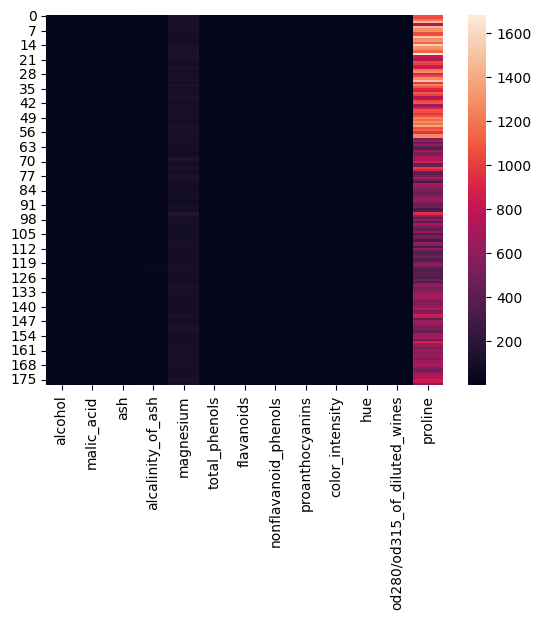

In [8]:
sb.heatmap(data)

## 4. Estandarización de los datos

Convierte el DataFrame en una matriz NumPy y estandariza los datos restando la media y dividiendo por la desviación estándar.

In [9]:
wine = np.matrix(data)
wine_norm = (wine - np.mean(wine)) / np.std(wine)

## 5. Cálculo de la Matriz de Covarianza

Calcula la matriz de covarianza del dataset estandarizado.

In [10]:
cov = np.cov(wine.T)

## 6. Cálculo de Autovalores y Autovectores

Calcula los autovalores y autovectores de la matriz de covarianza utilizando NumPy.

In [11]:
aval, avec = np.linalg.eig(cov)
print(aval)
print(avec)

[9.92017895e+04 1.72535266e+02 9.43811370e+00 4.99117861e+00
 1.22884523e+00 8.41063869e-01 2.78973523e-01 1.51381266e-01
 1.12096765e-01 8.20370314e-03 2.10723661e-02 3.75759789e-02
 7.17026032e-02]
[[-1.65926472e-03 -1.20340617e-03  1.68738094e-02  1.41446778e-01
  -2.03369773e-02  1.94120104e-01 -9.23280337e-01  2.84820658e-01
   8.66006124e-02  8.02924535e-03  1.56514071e-02 -1.49715080e-02
  -2.24499994e-03]
 [ 6.81015556e-04 -2.15498184e-03  1.22003373e-01  1.60389543e-01
   6.12883454e-01  7.42472963e-01  1.50109941e-01 -6.46744678e-02
   1.56621385e-02 -1.10903923e-02 -6.72955455e-02 -2.31876506e-02
  -1.85093501e-02]
 [-1.94905742e-04 -4.59369254e-03  5.19874304e-02 -9.77280992e-03
  -2.01755752e-02  4.17529118e-02 -4.50095493e-02 -1.49339532e-01
   7.36498524e-02 -1.73685673e-01  1.32063034e-01  9.54010643e-01
  -8.67996529e-02]
 [ 4.67130058e-03 -2.64503930e-02  9.38593003e-01 -3.30965260e-01
  -6.43523403e-02 -2.40653026e-02 -3.15265835e-02  1.51539118e-02
   2.04457785e-03

## 7. Ordenación de los componentes

Ordena los autovalores y sus correspondientes autovectores en orden descendente.

In [12]:
idx = np.argsort(aval)[::-1]

aval_sort = aval[idx]
avec_sort = avec[:,idx]

## 8. Varianza explicada por cada componente

Calcular y visualizar la varianza explicada por cada componente principal.

In [13]:
tot = sum(aval_sort)
expr = np.zeros(len(aval))
for i in range(0, len(aval_sort)):
    expr[i] = aval_sort[i]/tot

print(aval)
print(tot)
print(expr)

[9.92017895e+04 1.72535266e+02 9.43811370e+00 4.99117861e+00
 1.22884523e+00 8.41063869e-01 2.78973523e-01 1.51381266e-01
 1.12096765e-01 8.20370314e-03 2.10723661e-02 3.75759789e-02
 7.17026032e-02]
99391.5049915732
[9.98091230e-01 1.73591562e-03 9.49589576e-05 5.02173562e-05
 1.23636847e-05 8.46213034e-06 2.80681456e-06 1.52308053e-06
 1.12783044e-06 7.21415811e-07 3.78060267e-07 2.12013755e-07
 8.25392788e-08]


## 9. Proyección en 2D

Proyecta los datos en 2D usando las dos primeras componentes principales y visualiza la distribución de las clases en este nuevo espacio.

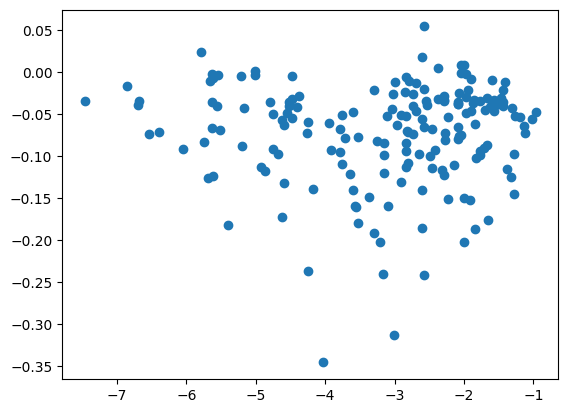

In [14]:
data_1 = wine_norm @ avec_sort[:,0]
data_2 = wine_norm @ avec_sort[:,1]

# convert matrix results to 1-D arrays for plotting
x = np.asarray(data_1)
y = np.asarray(data_2)

mpl.pyplot.scatter(x, y)

## 10. Proyección en 3D

Proyecta los datos en 3D usando las tres primeras componentes principales y visualiza la distribución de las clases en este nuevo espacio.

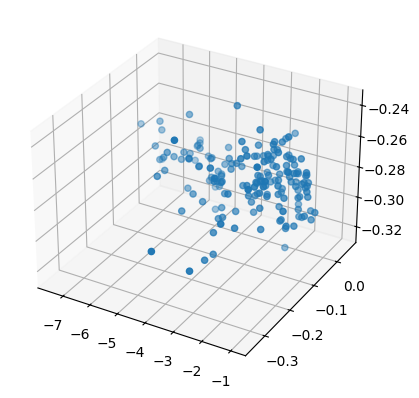

In [15]:
data_3 = wine_norm @ avec_sort[:,2]
z = np.asarray(data_3)

fig = mpl.pyplot.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(x, y, z, 'green')

# https://www.geeksforgeeks.org/python/three-dimensional-plotting-in-python-using-matplotlib/

In [ ]:
pca = sk.decomposition.PCA(n_components=3)
wine_pca = np.asarray(wine_norm)
pca.fit(wine_pca)
print(pca.explained_variance_ratio_)
print(pca.components_)

[9.98091230e-01 1.73591562e-03 9.49589576e-05]
[[ 1.65926472e-03 -6.81015556e-04  1.94905742e-04 -4.67130058e-03
   1.78680075e-02  9.89829680e-04  1.56728830e-03 -1.23086662e-04
   6.00607792e-04  2.32714319e-03  1.71380037e-04  7.04931645e-04
   9.99822937e-01]
 [ 1.20340617e-03  2.15498184e-03  4.59369254e-03  2.64503930e-02
   9.99344186e-01  8.77962152e-04 -5.18507284e-05 -1.35447892e-03
   5.00440040e-03  1.51003530e-02 -7.62673115e-04 -3.49536431e-03
  -1.77738095e-02]
 [ 1.68738094e-02  1.22003373e-01  5.19874304e-02  9.38593003e-01
  -2.97802484e-02 -4.04846439e-02 -8.54433387e-02  1.35107797e-02
  -2.46593824e-02  2.91398464e-01 -2.59776624e-02 -7.03239693e-02
   4.52868159e-03]]
